LOGISTIC REGRESSION
-------------------
Median House Value: 21.2
Accuracy: 0.8529411764705882

Confusion Matrix:
[[44  7]
 [ 8 43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        51
           1       0.86      0.84      0.85        51

    accuracy                           0.85       102
   macro avg       0.85      0.85      0.85       102
weighted avg       0.85      0.85      0.85       102



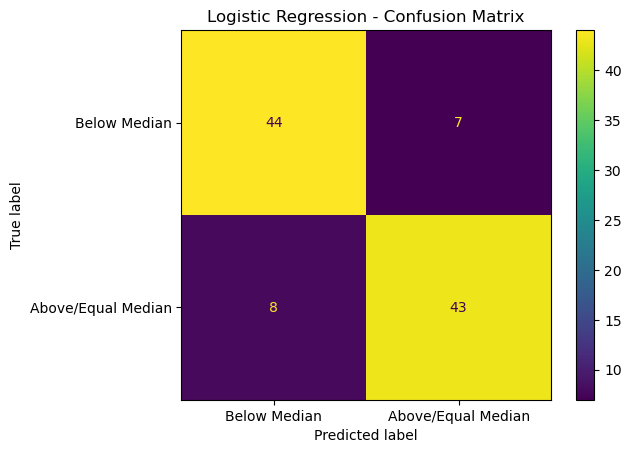

In [1]:
# Logistic Regression using Boston Housing Dataset

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 1. Load dataset
df = pd.read_csv("BostonHousing.csv")

# 2. Handle missing values
df["rm"] = df["rm"].fillna(df["rm"].mean())

# 3. Convert MEDV into binary classes
# 0 = Below median house value
# 1 = Above/equal median house value

median_value = df["medv"].median()

df["house_class"] = (df["medv"] >= median_value).astype(int)

# 4. Select input features
X = df.drop(["medv", "house_class"], axis=1)

# Target
y = df["house_class"]

# 5. Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# 8. Train model
model.fit(X_train, y_train)

# 9. Make predictions
y_pred = model.predict(X_test)

# 10. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("LOGISTIC REGRESSION")
print("-------------------")
print("Median House Value:", median_value)
print("Accuracy:", accuracy)

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 12. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 13. Display Confusion Matrix Graph
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Below Median", "Above/Equal Median"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()